In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('StudentSocialMediaAndMentalHealthImpact.csv')

In [3]:
df.shape

(5000, 13)

In [4]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


Check for table info


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


See the descriptive statistics of the dataset

In [6]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


Check if any of the values is null

In [7]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

Check for duplicates

In [8]:
df.duplicated().sum()

2

In [9]:
df[df.duplicated]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
2405,19,Female,Other,Undergraduate,LinkedIn,Education,6.1,202,1.0,2.1,5.8,High,4.1
2463,21,Male,USA,Undergraduate,Snapchat,Entertainment,3.9,126,5.1,2.6,7.1,Low,7.5


Before predicting, we need to understand the shape of what we are predicting

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

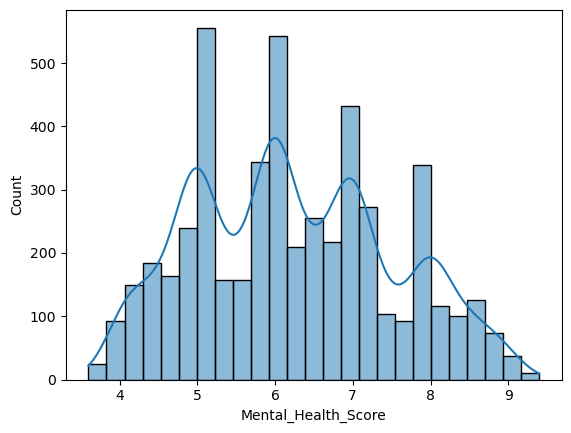

In [10]:
sns.histplot(df['Mental_Health_Score'], kde=True)

Corelation heatmap : Which numeric features actually move together with the target

<Axes: >

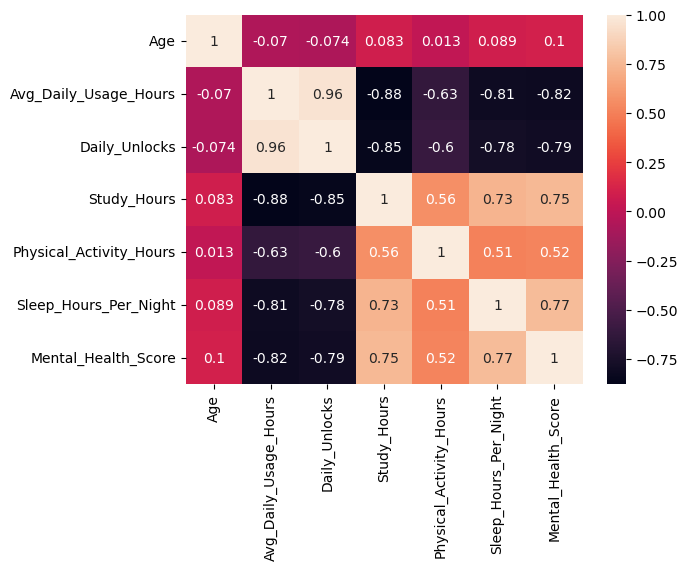

In [11]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

Does higher stress genuinely comes from lower score ?


In [12]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

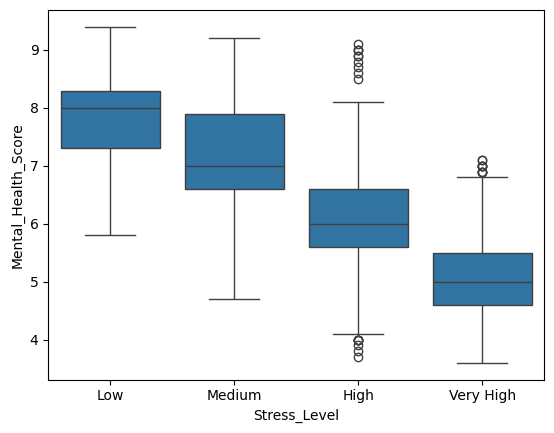

In [13]:
order = ['Low', 'Medium', 'High', 'Very High']
sns.boxplot(x='Stress_Level', y='Mental_Health_Score', data=df, order=order)

Daily usage hours Vs Mental Health Score

Does more time on social media relate to lower score ? (confirming the negative correlation)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

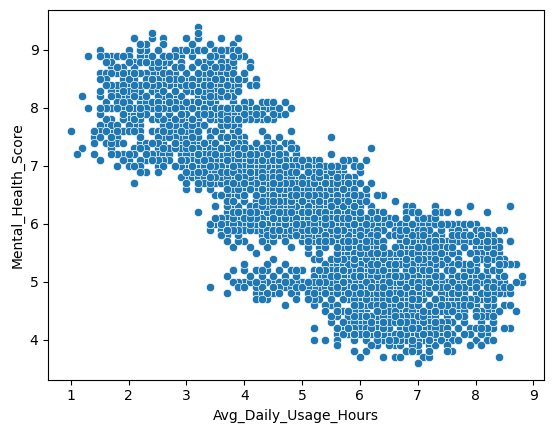

In [14]:
sns.scatterplot(x=df['Avg_Daily_Usage_Hours'], y=df['Mental_Health_Score'])

Sleep Hours vs Mental Health Score (confirming the positive correlation)

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

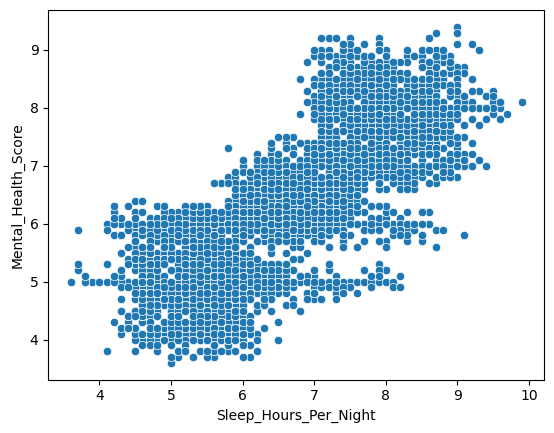

In [15]:
sns.scatterplot(x=df['Sleep_Hours_Per_Night'], y= df['Mental_Health_Score'])

Most used platforms

In [16]:
df['Most_Used_Platform'].value_counts()

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

In [17]:
platform_counts = df['Most_Used_Platform'].value_counts()
platform_counts

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

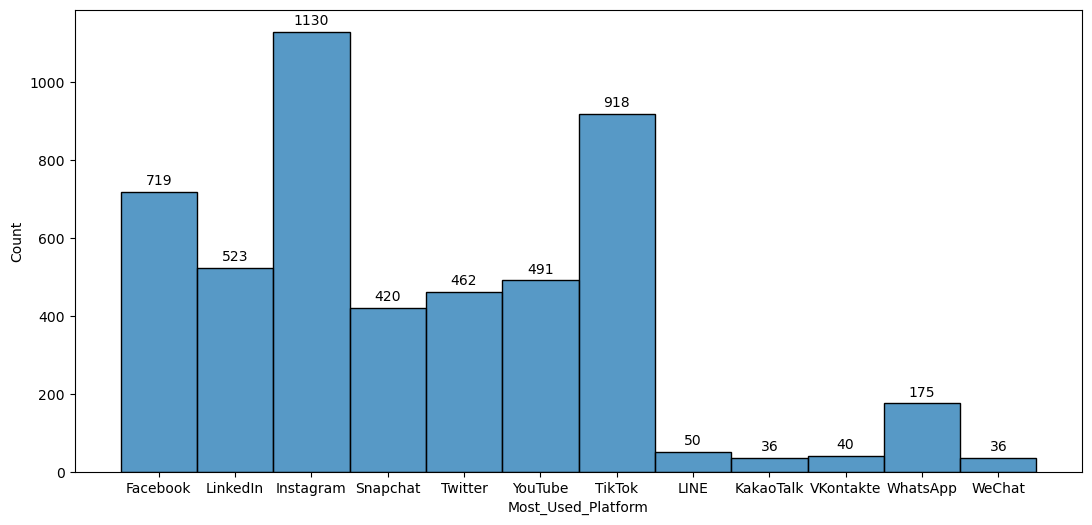

In [18]:
plt.figure(figsize=(13,6))
ax = sns.histplot(x=df['Most_Used_Platform'])
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

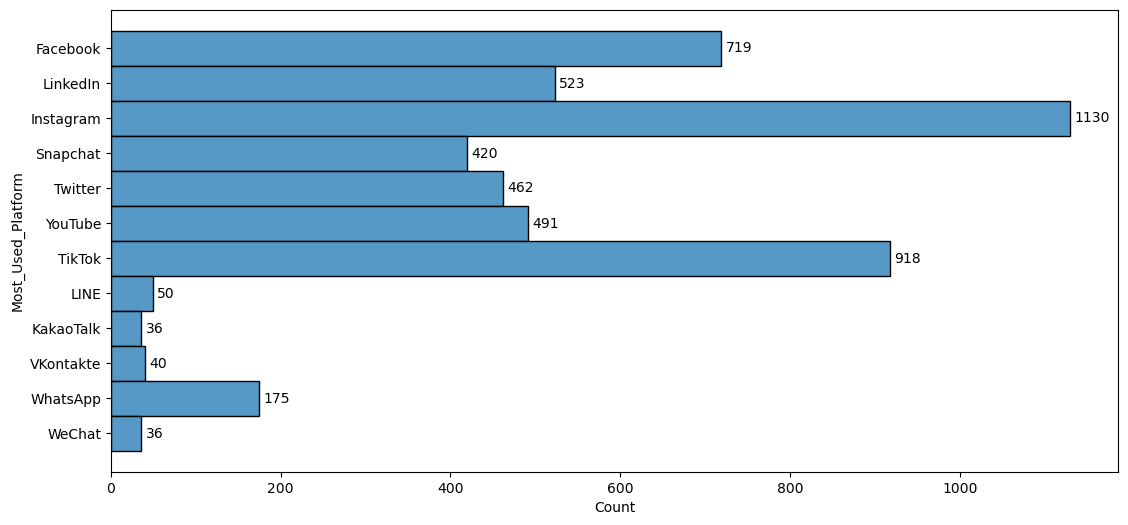

In [19]:
plt.figure(figsize=(13,6))
ax = sns.histplot(y=df['Most_Used_Platform'])
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

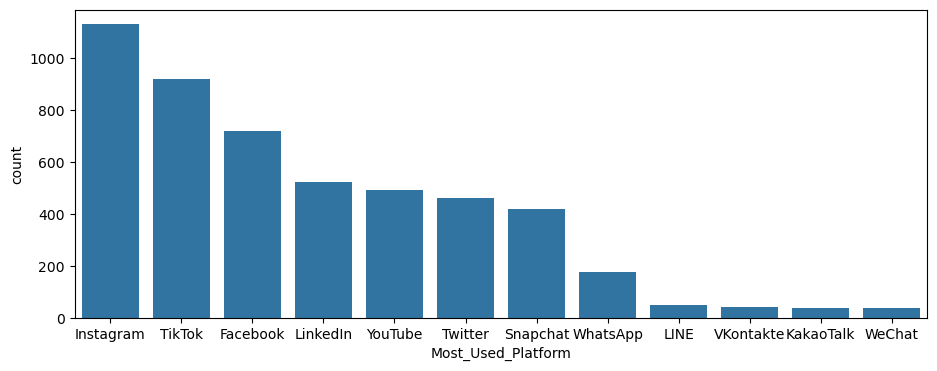

In [20]:
plt.figure(figsize=(11,4))
sns.countplot(x=df['Most_Used_Platform'], order=platform_counts.index)

Checking outliers (Mandatory step)

In [21]:
num_features =df.select_dtypes(include='number')
q1 = num_features.quantile(0.25)
q3 = num_features.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = (num_features < lower_bound) | (num_features > upper_bound)
outliers.sum()

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64

Data Cleaning

1. Drop duplicate rows

In [22]:
df = df.drop_duplicates()
df.shape

(4998, 13)

In [23]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.750760,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.668406,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In Physical activity hours, the minimum value is negative, so clip it to 0

In [24]:
df['Physical_Activity_Hours'] = df["Physical_Activity_Hours"].clip(lower=0)

In [25]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


Handling Skewness

In [26]:
num_cols = df.select_dtypes(include='number')
# skew value -> near to 0 (data centralized)
# skew value -> -ve (left skewed)
# skew value -> +ve (right skewed)
num_cols.skew()


Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

For correcting skewness, use Log transformation or Power Transformation

In [27]:
skewed_col = ['Study_Hours']        # Log Transformation
other_num_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']

In [28]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

Country column has 110 unique values and after One Hot Encoding, 111 columns will be formed. So, use the top 10 most frequent countries

In [29]:
dictionary = {}
values = df['Country'].value_counts()
country = values.index 
count = values.values
# for i in range(111):
#     print("country : ", country[i], " Count : ", count[i])
assert(len(country) == len(count))


In [30]:
top_countries = df['Country'].value_counts().index[:10].to_list()
top_countries

['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Turkey',
 'Mexico',
 'France']

In [31]:
def group_countries(country):
    if(country in top_countries):
        return country 
    else:
        return 'Other'

In [32]:
df['Grouped_country'] = df['Country'].apply(group_countries)

In [33]:
df['Grouped_country'].value_counts()

Grouped_country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

Encoding Strategy : 

Stress Level -> Ordinal encoding because categories have meaningful order.
Gender, Academic Level, Most used platform, purpose of use, country grouped -> One Hot Encoding because these don't have a natural order

In [34]:
ordinal_col = ['Stress_Level'] # Ordinal Encoding
normal_col = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Grouped_country"] # One Hot Encoding

In [35]:
feature_col = skewed_col + ordinal_col + normal_col + other_num_cols
print(len(feature_col))

12


Create pipelines for performing operations on these selected features

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder

# 1. Skewed Features
skew_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())
])

# 2. Numeric Features
plain_numeric_pipeline = Pipeline(steps=[
    ('scalar', StandardScaler())
])

# 3. Ordinal Features
ordinal_pipeline = Pipeline(steps=[
    ('encode', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])

# 4. Nominal Features
nominal_pipeline = Pipeline(steps=[
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

In [37]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ("Skewed_Pipeline", skew_pipeline, skewed_col),
    ("Plain_numeric", plain_numeric_pipeline, other_num_cols),
    ("Ordinal_Pipeline", ordinal_pipeline, ordinal_col),
    ("Nominal_Pipeline", nominal_pipeline, normal_col)
])

Train-Test Split

In [38]:
from sklearn.model_selection import train_test_split
X = df[feature_col]
Y = df['Mental_Health_Score']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.30, random_state=42)

Build a pipeline for the model

1. Always try the base model algo and decision tree

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression()),
])

lr_pipeline.fit(X_train, y_train)

# test predictions
lr_preds = lr_pipeline.predict(X_test)
lr_r2_test = r2_score(y_test, lr_preds)
lr_mae = mean_absolute_error(y_test, lr_preds)


# train predictions
lr_preds_train = lr_pipeline.predict(X_train)
lr_r2_train = r2_score(y_train, lr_preds_train)



In [40]:
print("Training accuracy : ", lr_r2_train)
print("Testing accuracy : ", lr_r2_test)
print("Mean abs error : ", lr_mae)

Training accuracy :  0.7235999615246915
Testing accuracy :  0.7396199881257794
Mean abs error :  0.5364190266927084


Create another model : Random Forest

In [41]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random forest', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X=X_train, y= y_train)

# test accuracy
rf_preds = rf_pipeline.predict(X_test)
r2_score_rf = r2_score(y_test, rf_preds)
rf_mae = mean_absolute_error(y_test, rf_preds)

# train accuracy
rf_preds_train = rf_pipeline.predict(X_train)
r2_score_rf_train = r2_score(y_train, rf_preds_train)


In [42]:
print("Training R2 score : ", r2_score_rf_train)
print("Test R2 score : ", r2_score_rf)
print("Mean absolute error : ", rf_mae)

Training R2 score :  0.9808669071711846
Test R2 score :  0.8769929126344471
Mean absolute error :  0.3485739333333334


Hyperparameter tuning

In [43]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'random forest__n_estimators' : [100, 200, 300],
    'random forest__max_depth': [5,10,15],
    'random forest__min_samples_split': [2, 5, 10],
    'random forest__min_samples_leaf': [1,2,4]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline, 
    param_distributions= param_grid,
    n_iter = 15,
    cv = 5,
    scoring='r2',
    random_state=42,
    n_jobs= -1       # Number of jobs to run in parallel : Take all currently free processors
)

random_search.fit(X_train, y_train)


/opt/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('Skewed_Pipeline',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('Plain_numeric',
                                                                               Pipeline(steps=[('scalar',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unlocks',
                                                                                'P...
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'Grouped_country'])])),
                                             ('random forest',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'random forest__max_depth': [5, 10, 15],
                                        'random forest__min_samples_leaf': [1,
                                                                            2,
                                                                            4],
                                        'random forest__min_samples_split': [2,
                                                                             5,
                                                                             10],
                                        'random forest__n_estimators': [100,
                                                                        200,
                                                                        300]},
                   random_state=42, scoring='r2')

In [44]:
random_search.best_params_

{'random forest__n_estimators': 200,
 'random forest__min_samples_split': 5,
 'random forest__min_samples_leaf': 2,
 'random forest__max_depth': 15}

In [45]:
rf_best_pipeline = random_search.best_estimator_
rf_best_preds = rf_best_pipeline.predict(X_test)
r2_score_best = r2_score(y_test, rf_best_preds)
mae_best = mean_absolute_error(y_test, rf_best_preds)
print("R2 score : ", r2_score_best)
print("MAE best : ", mae_best)

R2 score :  0.8651941447944332
MAE best :  0.3687738303343805


The hyperparameter tuning result is not as good as expected

Model Evaluation

In [46]:
from sklearn.metrics import root_mean_squared_error

# RMSE for linear regression
lr_rmse = root_mean_squared_error(y_test, lr_preds)

# RMSE for Random forest (plain)
rf_rmse = root_mean_squared_error(y_test, rf_preds)

# RMSE for tuned Random forest
rf_tuned_preds = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse = root_mean_squared_error(y_test, rf_tuned_preds)
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
rf_tuned_training_rmse = root_mean_squared_error(y_train, rf_tuned_training_preds)
r2_tuned_rf_test = r2_score(y_test, rf_tuned_preds)
r2_tuned_rf_train = r2_score(y_train, rf_tuned_training_preds)

results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Tuned Random Forest"],
    "R2": [lr_r2_test, r2_score_rf, r2_tuned_rf_test],
    "Training R2": [lr_r2_train, r2_score_rf_train, r2_tuned_rf_train],
    "RMSE": [lr_rmse, rf_rmse, rf_tuned_rmse]
})
results_df

,Model,R2,Training R2,RMSE
0,Linear Regression,0.739620,0.723600,0.676258
1,Random Forest,0.876993,0.980867,0.464808
2,Tuned Random Forest,0.865194,0.954719,0.486590


Save the best of the two models

In [47]:
# import joblib

# joblib.dump(rf_pipeline, "Mental_Health_model.pkl")

In [48]:
df.columns.to_list()

['Age',
 'Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Stress_Level',
 'Mental_Health_Score',
 'Grouped_country']

In [49]:
list(df.Academic_Level.unique())

['Undergraduate', 'Graduate', 'High School']

In [50]:
list(df.Most_Used_Platform.unique())

['Facebook',
 'LinkedIn',
 'Instagram',
 'Snapchat',
 'Twitter',
 'YouTube',
 'TikTok',
 'LINE',
 'KakaoTalk',
 'VKontakte',
 'WhatsApp',
 'WeChat']

In [51]:
list(df["Purpose_Of_Use"].unique())

['Networking', 'Education', 'Entertainment', 'News']

In [52]:
list(df['Stress_Level'].unique())

['Medium', 'Low', 'Very High', 'High']

In [53]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000
